In [1]:
from pathlib import Path

import pandas as pd

from weathergen.utils.plot_master import get_timeseries

In [2]:
runns = {
    "ne7wcujt": "small-tiny-6hx1_120x120",
    "h5flaxwu": "small-tiny-6hx1_360x120"
}

In [3]:
results_dir = Path('/p/home/jusers/grasse1/juwels/WeatherGenerator/results')
file_name = "validation_chkpt00000_rank0000.zip"
results_dir.is_dir()

True

In [4]:
KELVIN = 273.15
import numpy as np

def plot_sample(target, prediction, channel: str):
    x, y = target.lon.values, target.lat.values
    targets = target.values - KELVIN
    preds = prediction.values - KELVIN

    mask = np.isnan(targets)
    preds[mask] = np.nan

    fig, axs = plt.subplots(ncols=3, nrows=1, subplot_kw={"projection": ccrs.Mollweide()})
    for ax, data in zip(axs, [targets, preds, targets - preds], strict=True):
        ax.coastlines()
        im = ax.scatter(x, y, c=data, cmap="viridis", s=0.5, alpha=0.5)
        # plt.colorbar(im)

def plot_fsteps(result_path, sample: int, stream: str):
    with io.zarrio_reader(results_path) as reader:
        for fstep in reader.forecast_steps[1:]:
            item = reader.get_data(sample, stream, fstep)


def contents(results_path):
    with io.zarrio_reader(results_path) as reader:
        print(
            sorted(int(fstep) for fstep in reader.forecast_steps),
            sorted(int(sample) for sample in reader.samples),
            reader.streams,
        )


In [5]:
results_path = results_dir / "ne7wcujt" / file_name

In [6]:
ts_lead_time_at_init_0 = get_timeseries(results_path, "ERA5-Ocean", sample=0)
ts_lead_time_at_init_120 = get_timeseries(results_path, "ERA5-Ocean", sample=119)
ts_init_time_at_lead_1 = get_timeseries(results_path, "ERA5-Ocean", fstep=1)
ts_init_time_at_lead_120 = get_timeseries(results_path, "ERA5-Ocean", fstep=120)

In [7]:
ts_init_time_at_lead_120 = ts_init_time_at_lead_120.sort_values("source_interval_end")
ts_init_time_at_lead_1 = ts_init_time_at_lead_1.sort_values("source_interval_end")
ts_init_time_at_lead_120.index = ts_init_time_at_lead_120.source_interval_end.sort_values()
ts_init_time_at_lead_1.index = ts_init_time_at_lead_1.source_interval_end.sort_values()

In [8]:
ts_init_time_at_lead_1

,source_interval_start,source_interval_end,channel,target,prediction,stream,sample,forecast_step
source_interval_end,,,,,,,,
2023-06-01 06:00:00,2023-06-01 00:00:00,2023-06-01 06:00:00,sea_surface_temperature,12.539459,11.689545,ERA5-Ocean,0,1
2023-06-01 12:00:00,2023-06-01 06:00:00,2023-06-01 12:00:00,sea_surface_temperature,12.539459,11.663879,ERA5-Ocean,12,1
2023-06-01 18:00:00,2023-06-01 12:00:00,2023-06-01 18:00:00,sea_surface_temperature,12.539459,11.644714,ERA5-Ocean,24,1
2023-06-02 00:00:00,2023-06-01 18:00:00,2023-06-02 00:00:00,sea_surface_temperature,12.539459,11.642517,ERA5-Ocean,36,1
2023-06-02 06:00:00,2023-06-02 00:00:00,2023-06-02 06:00:00,sea_surface_temperature,12.539459,11.665100,ERA5-Ocean,48,1
...,...,...,...,...,...,...,...,...
2023-06-30 00:00:00,2023-06-29 18:00:00,2023-06-30 00:00:00,sea_surface_temperature,12.669281,12.058411,ERA5-Ocean,71,1
2023-06-30 06:00:00,2023-06-30 00:00:00,2023-06-30 06:00:00,sea_surface_temperature,12.669281,12.065735,ERA5-Ocean,83,1
2023-06-30 12:00:00,2023-06-30 06:00:00,2023-06-30 12:00:00,sea_surface_temperature,12.669281,12.068939,ERA5-Ocean,95,1


In [9]:
def transform_index(ts):
    init_time = ts["source_interval_start"][1]
    ts.index = pd.DatetimeIndex(init_time + ts.index * pd.Timedelta("6h"), name="date")
    return ts

<Axes: xlabel='date'>

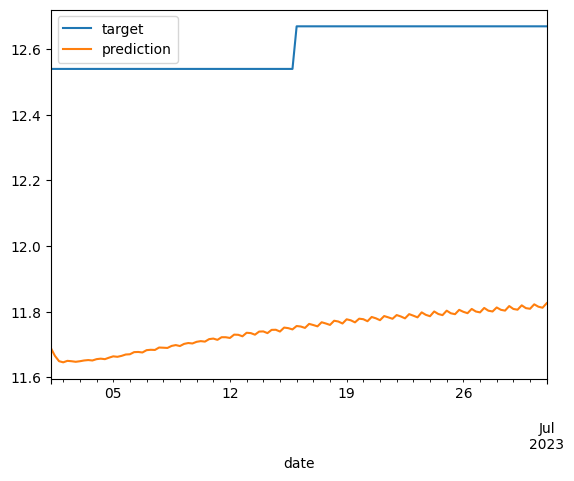

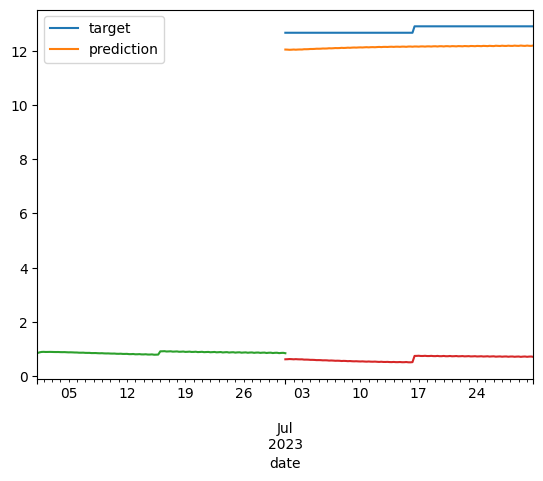

In [10]:
transform_index(ts_lead_time_at_init_0).plot(y=["target", "prediction"])
transform_index(ts_lead_time_at_init_120).plot(y=["target", "prediction"])
(ts_lead_time_at_init_0.target - ts_lead_time_at_init_0.prediction).plot()
(ts_lead_time_at_init_120.target - ts_lead_time_at_init_120.prediction).plot()

#ts_init_time_at_lead_1.plot(y=["target", "prediction"])
#ts_init_time_at_lead_120.plot(y=["target", "prediction"])
